# REVIEWER NOTICE — CROSS-VALIDATION STABILITY ANALYSIS

---

## **EXPERIMENT_BOX: CV_STABILITY**

This notebook analyzes **performance stability under data partitioning** — NOT generalization to new datasets.

---

## CRITICAL SCIENTIFIC SCOPE

| Aspect | What This IS | What This IS NOT |
|--------|--------------|------------------|
| **Purpose** | Stability analysis | Performance estimation |
| **Question** | How stable is performance across CV folds? | How well does model generalize? |
| **Claims** | Robustness under partitioning | Generalization to new datasets |
| **Dataset** | Sleep-EDF Expanded ONLY | NO new datasets |

---

## THIS NOTEBOOK DOES NOT:

- Introduce any new datasets
- Make generalization claims beyond Sleep-EDF Expanded
- Replace the main model evaluation
- Test cross-cohort or cross-dataset transfer

---

## THIS NOTEBOOK ANALYZES:

1. **Fold-to-fold variance**: How much does performance vary across CV folds?
2. **Seed sensitivity**: How much does random initialization affect results?
3. **Statistical robustness**: Are performance differences significant?
4. **Confidence intervals**: What is the reliable performance range?

---

## EXPERIMENTAL PROTOCOL

1. **Dataset**: Sleep-EDF Expanded (78 subjects) — ONLY this dataset
2. **CV Strategy**: Subject-wise StratifiedGroupKFold (5-fold)
3. **Repetitions**: 5 different random seeds
4. **Total evaluations**: 5 folds × 5 seeds = 25 train/test splits
5. **Metrics**: Mean ± std across all splits

---

## WHAT THE RESULTS SUPPORT

- **Low variance** → Model is stable, results are reproducible
- **High variance** → Results may be sensitive to specific train/test splits
- **Confidence intervals** → Reliable range for reported performance

---

**Notebook generated**: `datetime.now().isoformat()` will be set at execution time.

# Cross-Validation Stability Analysis: Sleep-EDF Expanded

## Section 0: Analysis Overview

### Why Stability Analysis?

Machine learning models can exhibit **variance** due to:
- Random train/test partitioning
- Random weight initialization
- Stochastic optimization

This notebook quantifies this variance to support **robustness claims**.

### Analysis Components

| Component | Method | Purpose |
|-----------|--------|--------|
| **Fold variance** | 5-fold CV | Sensitivity to data partition |
| **Seed variance** | 5 random seeds | Sensitivity to initialization |
| **Combined** | 5 × 5 = 25 runs | Overall stability estimate |

### Reported Statistics

- Mean ± standard deviation
- 95% confidence interval
- Min/max range
- Coefficient of variation (CV%)

---

### ⚠️ Reproducibility & Scope Statement (For Reviewers)

This notebook evaluates **stability under subject-wise data partitioning**.

| Aspect | Description |
|--------|-------------|
| **Purpose** | Quantify variance in performance metrics across CV folds and random seeds |
| **Scope** | Robustness analysis ONLY — NOT generalization or cross-dataset performance |
| **Dataset** | Sleep-EDF Expanded (single dataset, 78 subjects) |
| **Claims Supported** | Reproducibility, stability, confidence intervals |
| **Claims NOT Supported** | Cross-cohort generalization, cross-dataset transfer |

**Checkpoint Guarantee**: Every CV run saves a checkpoint with `train_subjects` and `test_subjects` to `results/cv_stability/checkpoints/`. These can be audited independently.

## Section 1: Imports and Configuration

In [1]:
# ===================================================================
# IMPORTS AND CONFIGURATION
# ===================================================================

import os
import sys
import json
import pickle
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scientific computing
from scipy import stats

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix,
    precision_recall_fscore_support, matthews_corrcoef
)

# XGBoost
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================================
# EXPERIMENT CONFIGURATION
# ===================================================================

# Experiment identification
EXPERIMENT_BOX = "CV_STABILITY"  # Distinguishes this from other experiments
DATASET_NAME = "Sleep-EDF Expanded"  # Single dataset only

# CV Configuration
N_FOLDS = 5  # Number of CV folds
RANDOM_SEEDS = [42, 123, 456, 789, 1024]  # Seeds for repeated CV
N_SEEDS = len(RANDOM_SEEDS)
TOTAL_RUNS = N_FOLDS * N_SEEDS  # 25 total evaluations

# Paths
PROJECT_ROOT = Path.cwd()
CHECKPOINT_DIR = PROJECT_ROOT / 'cache' / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'
OUTPUT_DIR = RESULTS_DIR / 'cv_stability'
FEATURES_CACHE = PROJECT_ROOT / 'cache' / 'features'
DATA_DIR = PROJECT_ROOT / 'sleep-edfx'

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Sleep stage mapping (AASM)
STAGE_MAPPING = {
    0: 'Wake',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'REM'
}

print("Cross-Validation Stability Analysis")
print("="*70)
print(f"EXPERIMENT_BOX:   {EXPERIMENT_BOX}")
print(f"DATASET_NAME:     {DATASET_NAME}")
print(f"N_FOLDS:          {N_FOLDS}")
print(f"N_SEEDS:          {N_SEEDS}")
print(f"TOTAL_RUNS:       {TOTAL_RUNS}")
print("-"*70)
print(f"Project root:     {PROJECT_ROOT}")
print(f"Output dir:       {OUTPUT_DIR}")
print("="*70)
print("\n⚠️ This analysis uses Sleep-EDF Expanded ONLY")
print("⚠️ NO new datasets are introduced")
print("⚠️ Results support ROBUSTNESS claims, not generalization")

Cross-Validation Stability Analysis
EXPERIMENT_BOX:   CV_STABILITY
DATASET_NAME:     Sleep-EDF Expanded
N_FOLDS:          5
N_SEEDS:          5
TOTAL_RUNS:       25
----------------------------------------------------------------------
Project root:     /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection
Output dir:       /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability

⚠️ This analysis uses Sleep-EDF Expanded ONLY
⚠️ NO new datasets are introduced
⚠️ Results support ROBUSTNESS claims, not generalization


## Section 2: Evaluation Metrics

In [2]:
# ===================================================================
# EVALUATION METRICS
# ===================================================================

def compute_metrics(y_true, y_pred):
    """
    Compute evaluation metrics for sleep staging.
    
    Returns:
    --------
    dict : Dictionary containing all metrics
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
        'kappa': cohen_kappa_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred)
    }
    
    # Per-class metrics
    classes = np.unique(np.concatenate([y_true, y_pred]))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=classes, zero_division=0
    )
    
    metrics['per_class_recall'] = dict(zip(classes.tolist(), recall.tolist()))
    metrics['per_class_f1'] = dict(zip(classes.tolist(), f1.tolist()))
    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred, labels=classes)
    
    return metrics


def compute_stability_stats(values, metric_name):
    """
    Compute stability statistics for a metric.
    
    Parameters:
    -----------
    values : list or array
        Metric values across runs
    metric_name : str
        Name of the metric
        
    Returns:
    --------
    dict : Statistics including mean, std, CI, CV%
    """
    values = np.array(values)
    n = len(values)
    
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)  # Sample std
    
    # 95% confidence interval
    se = std_val / np.sqrt(n)
    t_critical = stats.t.ppf(0.975, df=n-1)
    ci_lower = mean_val - t_critical * se
    ci_upper = mean_val + t_critical * se
    
    # Coefficient of variation (as percentage)
    cv_percent = (std_val / mean_val) * 100 if mean_val > 0 else 0
    
    return {
        'metric': metric_name,
        'n': n,
        'mean': mean_val,
        'std': std_val,
        'se': se,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'cv_percent': cv_percent,
        'min': np.min(values),
        'max': np.max(values),
        'range': np.max(values) - np.min(values),
        'values': values.tolist()
    }


print("✓ Evaluation metrics defined")
print("✓ Stability statistics function defined")

✓ Evaluation metrics defined
✓ Stability statistics function defined


## Section 3: Load Data (Sleep-EDF Expanded ONLY)

In [3]:
# ===================================================================
# LOAD DATA (SLEEP-EDF EXPANDED ONLY)
# ===================================================================
"""
This analysis uses ONLY Sleep-EDF Expanded.
NO new datasets are introduced.
"""

print("="*70)
print("LOADING DATA (SLEEP-EDF EXPANDED ONLY)")
print("="*70)
print("⚠️ This notebook uses a SINGLE dataset for stability analysis")
print("⚠️ NO generalization claims are made")
print("="*70)

def load_features():
    """Load preprocessed Sleep-EDF Expanded features."""
    X_path = FEATURES_CACHE / 'X_df.pkl'
    y_path = FEATURES_CACHE / 'y.pkl'
    subjects_path = FEATURES_CACHE / 'subjects.pkl'
    feature_names_path = FEATURES_CACHE / 'feature_names.pkl'
    
    if not X_path.exists():
        raise FileNotFoundError(
            f"Features not found: {FEATURES_CACHE}\n"
            "Please run the main notebook (01_main_model.ipynb) first."
        )
    
    X_df = pd.read_pickle(X_path)
    y = np.array(pd.read_pickle(y_path))
    subjects_raw = pd.read_pickle(subjects_path)
    subjects = np.array([str(s)[:6] for s in subjects_raw])
    
    feature_names = pd.read_pickle(feature_names_path) if feature_names_path.exists() else X_df.columns.tolist()
    
    return X_df, y, subjects, feature_names


try:
    X_df, y, subjects, feature_names = load_features()
    
    ALL_SUBJECTS = sorted(np.unique(subjects).tolist())
    
    print(f"\n✓ Data loaded (Sleep-EDF Expanded)")
    print(f"  Subjects: {len(ALL_SUBJECTS)}")
    print(f"  Epochs:   {len(y)}")
    print(f"  Features: {len(feature_names)}")
    print(f"  Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
    
    DATA_LOADED = True
    
except FileNotFoundError as e:
    print(f"\n❌ {e}")
    DATA_LOADED = False
    X_df, y, subjects, feature_names = None, None, None, []
    ALL_SUBJECTS = []

LOADING DATA (SLEEP-EDF EXPANDED ONLY)
⚠️ This notebook uses a SINGLE dataset for stability analysis
⚠️ NO generalization claims are made

✓ Data loaded (Sleep-EDF Expanded)
  Subjects: 153
  Epochs:   414813
  Features: 108
  Class distribution: {0: 285286, 1: 21521, 2: 69132, 3: 13039, 4: 25835}


## Section 4: Model Definition

In [4]:
# ===================================================================
# MODEL DEFINITION
# ===================================================================

class WeightedEnsemble:
    """Weighted probability ensemble of XGBoost and LinearSVC."""
    
    def __init__(self, xgb_model, svc_model, xgb_weight=0.7, svc_weight=0.3):
        self.xgb_model = xgb_model
        self.svc_model = svc_model
        self.xgb_weight = xgb_weight
        self.svc_weight = svc_weight
    
    def predict_proba(self, X):
        xgb_proba = self.xgb_model.predict_proba(X)
        svc_proba = self.svc_model.predict_proba(X)
        return self.xgb_weight * xgb_proba + self.svc_weight * svc_proba
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)


def train_model(X_train, y_train, seed):
    """
    Train XGBoost + LinearSVC ensemble.
    
    Parameters:
    -----------
    X_train : array-like
        Training features (scaled)
    y_train : array-like
        Training labels
    seed : int
        Random seed
        
    Returns:
    --------
    WeightedEnsemble : Trained ensemble model
    """
    # XGBoost
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        objective='multi:softprob',
        num_class=5,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    
    # Calibrated LinearSVC
    base_svc = LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=seed,
        dual='auto'
    )
    svc_model = CalibratedClassifierCV(
        estimator=base_svc,
        method='sigmoid',
        cv=5
    )
    svc_model.fit(X_train, y_train)
    
    # Ensemble
    ensemble = WeightedEnsemble(xgb_model, svc_model, xgb_weight=0.7, svc_weight=0.3)
    
    return ensemble


print("✓ Model definition complete")
print("  - XGBoost classifier")
print("  - Calibrated LinearSVC")
print("  - Weighted ensemble (0.7/0.3)")

✓ Model definition complete
  - XGBoost classifier
  - Calibrated LinearSVC
  - Weighted ensemble (0.7/0.3)


## Section 5: Repeated Cross-Validation

In [5]:
# ===================================================================
# REPEATED CROSS-VALIDATION
# ===================================================================
"""
EXPERIMENTAL PROTOCOL:
1. 5-fold subject-wise StratifiedGroupKFold
2. Repeated with 5 different random seeds
3. Total: 25 train/test splits
4. Report mean ± std across all 25 runs
"""

print("="*70)
print("REPEATED CROSS-VALIDATION")
print("="*70)
print(f"Folds:       {N_FOLDS}")
print(f"Seeds:       {RANDOM_SEEDS}")
print(f"Total runs:  {TOTAL_RUNS}")
print("="*70)

# ─────────────────────────────────────────────────────────────────
# CHECKPOINT RESUME: Load completed runs from previous session
# ─────────────────────────────────────────────────────────────────
def load_completed_cv_runs(output_dir, random_seeds, n_folds):
    """Load completed CV runs from checkpoint files.
    
    Parameters:
    -----------
    output_dir : Path
        Directory containing checkpoints subfolder
    random_seeds : list
        List of random seeds used in CV
    n_folds : int
        Number of CV folds
        
    Returns:
    --------
    tuple : (completed dict, loaded_results list)
    """
    completed = {}
    checkpoint_dir = output_dir / 'checkpoints'
    
    if not checkpoint_dir.exists():
        return completed, []
    
    loaded_results = []
    for seed in random_seeds:
        for fold in range(n_folds):
            checkpoint_path = checkpoint_dir / f'cv_run_seed{seed}_fold{fold}.pkl'
            if checkpoint_path.exists():
                try:
                    with open(checkpoint_path, 'rb') as f:
                        checkpoint_data = pickle.load(f)
                    completed[(seed, fold)] = checkpoint_data
                    
                    # Reconstruct result for all_results list
                    result = {
                        'seed': seed,
                        'fold': fold,
                        'run_id': random_seeds.index(seed) * n_folds + fold + 1,
                        'n_train_subjects': len(checkpoint_data.get('train_subjects', [])),
                        'n_test_subjects': len(checkpoint_data.get('test_subjects', [])),
                        'n_train_epochs': checkpoint_data.get('n_train_epochs', 0),
                        'n_test_epochs': checkpoint_data.get('n_test_epochs', 0),
                        'train_subjects': checkpoint_data.get('train_subjects', []),
                        'test_subjects': checkpoint_data.get('test_subjects', []),
                        'metrics': {
                            **checkpoint_data.get('metrics', {}),
                            'per_class_recall': checkpoint_data.get('per_class_metrics', {}).get('recall', {}),
                            'per_class_f1': checkpoint_data.get('per_class_metrics', {}).get('f1', {}),
                        },
                        'y_true': [],  # Not stored in checkpoint
                        'y_pred': [],  # Not stored in checkpoint
                    }
                    loaded_results.append(result)
                except Exception as e:
                    print(f"  ⚠️ Failed to load checkpoint {checkpoint_path}: {e}")
    
    return completed, loaded_results

all_results = []

if DATA_LOADED:
    
    # Load existing checkpoints
    completed_runs, loaded_results = load_completed_cv_runs(OUTPUT_DIR, RANDOM_SEEDS, N_FOLDS)
    
    if completed_runs:
        print(f"\n✓ Found {len(completed_runs)} completed runs from checkpoint")
        all_results.extend(loaded_results)
        for (seed, fold), _ in sorted(completed_runs.items()):
            print(f"  - Seed {seed}, Fold {fold+1} (CACHED)")
    
    X_values = X_df.values
    run_count = len(completed_runs)
    
    for seed_idx, seed in enumerate(RANDOM_SEEDS):
        print(f"\n{'─'*70}")
        print(f"SEED {seed_idx + 1}/{N_SEEDS}: {seed}")
        print(f"{'─'*70}")
        
        np.random.seed(seed)
        
        # Subject-wise stratified k-fold
        cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
        
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_values, y, groups=subjects)):
            
            # ─────────────────────────────────────────────────────────────────
            # CHECKPOINT RESUME: Skip if already completed
            # ─────────────────────────────────────────────────────────────────
            if (seed, fold_idx) in completed_runs:
                print(f"  Fold {fold_idx + 1}/{N_FOLDS} - SKIPPED (from checkpoint)")
                continue
            
            run_count += 1
            
            # Split data
            X_train, X_test = X_values[train_idx], X_values[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            subjects_train = subjects[train_idx]
            subjects_test = subjects[test_idx]
            
            train_subject_ids = sorted(np.unique(subjects_train).tolist())
            test_subject_ids = sorted(np.unique(subjects_test).tolist())
            
            # Verify no overlap
            overlap = set(train_subject_ids) & set(test_subject_ids)
            if overlap:
                raise ValueError(f"Subject overlap detected: {overlap}")
            
            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # Train model
            model = train_model(X_train_scaled, y_train, seed)
            
            # Evaluate
            y_pred = model.predict(X_test_scaled)
            metrics = compute_metrics(y_test, y_pred)
            
            # Store result
            result = {
                'seed': seed,
                'fold': fold_idx,
                'run_id': run_count,
                'n_train_subjects': len(train_subject_ids),
                'n_test_subjects': len(test_subject_ids),
                'n_train_epochs': len(y_train),
                'n_test_epochs': len(y_test),
                'train_subjects': train_subject_ids,
                'test_subjects': test_subject_ids,
                'metrics': metrics,
                'y_true': y_test.tolist(),
                'y_pred': y_pred.tolist(),
            }
            all_results.append(result)
            
            # ─────────────────────────────────────────────────────────────────
            # SAVE PER-RUN CHECKPOINT (REQUIRED FOR REPRODUCIBILITY AUDIT)
            # ─────────────────────────────────────────────────────────────────
            checkpoint = {
                'experiment_box': EXPERIMENT_BOX,
                'dataset_name': DATASET_NAME,
                'random_seed': seed,
                'fold_id': fold_idx,
                'train_subjects': train_subject_ids,
                'test_subjects': test_subject_ids,
                'metrics': {
                    k: v for k, v in metrics.items() 
                    if k not in ['confusion_matrix', 'per_class_recall', 'per_class_f1']
                },
                'per_class_metrics': {
                    'recall': metrics.get('per_class_recall', {}),
                    'f1': metrics.get('per_class_f1', {}),
                },
                'n_train_epochs': len(y_train),
                'n_test_epochs': len(y_test),
                'timestamp': datetime.now().isoformat(),
            }
            
            # REQUIRED FIELD VALIDATION (raises error if missing)
            REQUIRED_FIELDS = [
                'experiment_box', 'dataset_name', 'random_seed',
                'train_subjects', 'test_subjects', 'metrics'
            ]
            missing = [k for k in REQUIRED_FIELDS if k not in checkpoint]
            if missing:
                raise ValueError(f"Checkpoint missing required fields: {missing}")
            
            # Save checkpoint
            checkpoint_dir = OUTPUT_DIR / 'checkpoints'
            checkpoint_dir.mkdir(parents=True, exist_ok=True)
            checkpoint_path = checkpoint_dir / f'cv_run_seed{seed}_fold{fold_idx}.pkl'
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(checkpoint, f)
            
            print(f"  Fold {fold_idx + 1}/{N_FOLDS}: "
                  f"Acc={metrics['accuracy']:.4f}, "
                  f"F1={metrics['macro_f1']:.4f}, "
                  f"κ={metrics['kappa']:.4f} "
                  f"(train={len(train_subject_ids)}, test={len(test_subject_ids)})")
    
    print(f"\n{'='*70}")
    print(f"✓ Completed {len(all_results)} runs ({N_SEEDS} seeds × {N_FOLDS} folds)")
    print(f"✓ Checkpoints saved to: {OUTPUT_DIR / 'checkpoints'}")
    print(f"{'='*70}")
    
    CV_COMPLETE = True
    
else:
    print("\n❌ Cannot run CV: data not loaded")
    CV_COMPLETE = False

REPEATED CROSS-VALIDATION
Folds:       5
Seeds:       [42, 123, 456, 789, 1024]
Total runs:  25

✓ Found 2 completed runs from checkpoint
  - Seed 42, Fold 1 (CACHED)
  - Seed 42, Fold 2 (CACHED)

──────────────────────────────────────────────────────────────────────
SEED 1/5: 42
──────────────────────────────────────────────────────────────────────
  Fold 1/5 - SKIPPED (from checkpoint)
  Fold 2/5 - SKIPPED (from checkpoint)
  Fold 3/5: Acc=0.9138, F1=0.7528, κ=0.8201 (train=122, test=31)
  Fold 4/5: Acc=0.8903, F1=0.7194, κ=0.7749 (train=123, test=30)
  Fold 5/5: Acc=0.9105, F1=0.7622, κ=0.8135 (train=122, test=31)

──────────────────────────────────────────────────────────────────────
SEED 2/5: 123
──────────────────────────────────────────────────────────────────────
  Fold 1/5: Acc=0.9004, F1=0.7356, κ=0.7919 (train=123, test=30)
  Fold 2/5: Acc=0.8867, F1=0.7224, κ=0.7717 (train=122, test=31)
  Fold 3/5: Acc=0.8991, F1=0.7349, κ=0.7947 (train=122, test=31)
  Fold 4/5: Acc=0.9144,

## Section 6: Stability Analysis

In [6]:
# ===================================================================
# STABILITY ANALYSIS
# ===================================================================

print("="*70)
print("STABILITY ANALYSIS RESULTS")
print("="*70)

if CV_COMPLETE and len(all_results) > 0:
    
    # Extract metrics from all runs
    macro_f1_values = [r['metrics']['macro_f1'] for r in all_results]
    balanced_acc_values = [r['metrics']['balanced_accuracy'] for r in all_results]
    kappa_values = [r['metrics']['kappa'] for r in all_results]
    accuracy_values = [r['metrics']['accuracy'] for r in all_results]
    
    # Compute stability statistics
    stability_stats = {
        'macro_f1': compute_stability_stats(macro_f1_values, 'Macro F1'),
        'balanced_accuracy': compute_stability_stats(balanced_acc_values, 'Balanced Accuracy'),
        'kappa': compute_stability_stats(kappa_values, "Cohen's Kappa"),
        'accuracy': compute_stability_stats(accuracy_values, 'Accuracy'),
    }
    
    # ─────────────────────────────────────────────────────────────────
    # PRIMARY METRICS TABLE (Required)
    # ─────────────────────────────────────────────────────────────────
    
    print("\n📊 PRIMARY METRICS (Mean ± Std across 25 runs)")
    print("─"*80)
    print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'95% CI':>20} {'CV%':>10}")
    print("─"*80)
    
    for key in ['macro_f1', 'balanced_accuracy', 'kappa']:
        s = stability_stats[key]
        ci_str = f"[{s['ci_lower']:.4f}, {s['ci_upper']:.4f}]"
        print(f"{s['metric']:<20} {s['mean']:>10.4f} {s['std']:>10.4f} {ci_str:>20} {s['cv_percent']:>10.2f}%")
    
    print("─"*80)
    
    # ─────────────────────────────────────────────────────────────────
    # STABILITY INTERPRETATION
    # ─────────────────────────────────────────────────────────────────
    
    print("\n📈 STABILITY INTERPRETATION")
    print("─"*60)
    
    for key in ['macro_f1', 'balanced_accuracy', 'kappa']:
        s = stability_stats[key]
        
        # Interpret coefficient of variation
        if s['cv_percent'] < 2:
            stability_label = "✓ EXCELLENT (<2%)"
        elif s['cv_percent'] < 5:
            stability_label = "○ GOOD (<5%)"
        elif s['cv_percent'] < 10:
            stability_label = "△ MODERATE (<10%)"
        else:
            stability_label = "⚠️ HIGH (≥10%)"
        
        print(f"{s['metric']:<20}: CV% = {s['cv_percent']:.2f}% → {stability_label}")
    
    print("─"*60)
    print("\nCV% (Coefficient of Variation) = Std / Mean × 100")
    print("Lower CV% indicates more stable/reproducible results.")
    
    # ─────────────────────────────────────────────────────────────────
    # DETAILED BREAKDOWN
    # ─────────────────────────────────────────────────────────────────
    
    print("\n" + "="*70)
    print("DETAILED BREAKDOWN")
    print("="*70)
    
    print(f"\n{'Metric':<20} {'Min':>10} {'Max':>10} {'Range':>10}")
    print("─"*50)
    
    for key in ['macro_f1', 'balanced_accuracy', 'kappa', 'accuracy']:
        s = stability_stats[key]
        print(f"{s['metric']:<20} {s['min']:>10.4f} {s['max']:>10.4f} {s['range']:>10.4f}")
    
    print("─"*50)
    
    ANALYSIS_COMPLETE = True
    
else:
    print("\n❌ No results to analyze")
    stability_stats = None
    ANALYSIS_COMPLETE = False

STABILITY ANALYSIS RESULTS

📊 PRIMARY METRICS (Mean ± Std across 25 runs)
────────────────────────────────────────────────────────────────────────────────
Metric                     Mean        Std               95% CI        CV%
────────────────────────────────────────────────────────────────────────────────
Macro F1                 0.7416     0.0151     [0.7354, 0.7478]       2.03%
Balanced Accuracy        0.7280     0.0177     [0.7206, 0.7353]       2.44%
Cohen's Kappa            0.8010     0.0156     [0.7945, 0.8074]       1.95%
────────────────────────────────────────────────────────────────────────────────

📈 STABILITY INTERPRETATION
────────────────────────────────────────────────────────────
Macro F1            : CV% = 2.03% → ○ GOOD (<5%)
Balanced Accuracy   : CV% = 2.44% → ○ GOOD (<5%)
Cohen's Kappa       : CV% = 1.95% → ✓ EXCELLENT (<2%)
────────────────────────────────────────────────────────────

CV% (Coefficient of Variation) = Std / Mean × 100
Lower CV% indicates more st

## Section 7: Variance Decomposition (Fold vs Seed)

In [7]:
# ===================================================================
# VARIANCE DECOMPOSITION: FOLD VS SEED
# ===================================================================
"""
Analyze variance sources:
- Fold variance: Sensitivity to data partition
- Seed variance: Sensitivity to random initialization
"""

print("="*70)
print("VARIANCE DECOMPOSITION")
print("="*70)

if ANALYSIS_COMPLETE:
    
    # Organize results by seed and fold
    results_matrix = np.zeros((N_SEEDS, N_FOLDS))
    
    for result in all_results:
        seed_idx = RANDOM_SEEDS.index(result['seed'])
        fold_idx = result['fold']
        results_matrix[seed_idx, fold_idx] = result['metrics']['macro_f1']
    
    # Variance across folds (for each seed)
    fold_variances = np.var(results_matrix, axis=1, ddof=1)
    mean_fold_variance = np.mean(fold_variances)
    
    # Variance across seeds (for each fold)
    seed_variances = np.var(results_matrix, axis=0, ddof=1)
    mean_seed_variance = np.mean(seed_variances)
    
    # Total variance
    total_variance = np.var(results_matrix.flatten(), ddof=1)
    
    print("\n📊 MACRO F1 VARIANCE DECOMPOSITION")
    print("─"*60)
    print(f"{'Source':<25} {'Variance':>15} {'% of Total':>15}")
    print("─"*60)
    
    fold_pct = (mean_fold_variance / total_variance) * 100 if total_variance > 0 else 0
    seed_pct = (mean_seed_variance / total_variance) * 100 if total_variance > 0 else 0
    
    print(f"{'Fold (data partition)':<25} {mean_fold_variance:>15.6f} {fold_pct:>14.1f}%")
    print(f"{'Seed (initialization)':<25} {mean_seed_variance:>15.6f} {seed_pct:>14.1f}%")
    print(f"{'Total':<25} {total_variance:>15.6f} {'100.0':>14}%")
    print("─"*60)
    
    # Interpretation
    print("\n📈 INTERPRETATION")
    if fold_pct > seed_pct:
        print(f"  → Fold variance ({fold_pct:.1f}%) > Seed variance ({seed_pct:.1f}%)")
        print("  → Performance is more sensitive to DATA PARTITION than initialization")
        print("  → This is typical for subject-wise CV")
    else:
        print(f"  → Seed variance ({seed_pct:.1f}%) > Fold variance ({fold_pct:.1f}%)")
        print("  → Performance is more sensitive to RANDOM INITIALIZATION")
        print("  → Consider fixing random seeds for reproducibility")
    
    # Per-seed statistics
    print("\n" + "="*70)
    print("PER-SEED STATISTICS (Macro F1)")
    print("="*70)
    print(f"{'Seed':>8} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
    print("─"*60)
    
    for seed_idx, seed in enumerate(RANDOM_SEEDS):
        seed_values = results_matrix[seed_idx, :]
        print(f"{seed:>8} {np.mean(seed_values):>12.4f} {np.std(seed_values, ddof=1):>12.4f} "
              f"{np.min(seed_values):>12.4f} {np.max(seed_values):>12.4f}")
    
    print("─"*60)
    
    # Per-fold statistics
    print("\n" + "="*70)
    print("PER-FOLD STATISTICS (Macro F1)")
    print("="*70)
    print(f"{'Fold':>8} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
    print("─"*60)
    
    for fold_idx in range(N_FOLDS):
        fold_values = results_matrix[:, fold_idx]
        print(f"{fold_idx + 1:>8} {np.mean(fold_values):>12.4f} {np.std(fold_values, ddof=1):>12.4f} "
              f"{np.min(fold_values):>12.4f} {np.max(fold_values):>12.4f}")
    
    print("─"*60)
    
    DECOMPOSITION_COMPLETE = True
    
else:
    print("\n❌ Analysis not complete")
    DECOMPOSITION_COMPLETE = False

VARIANCE DECOMPOSITION

📊 MACRO F1 VARIANCE DECOMPOSITION
────────────────────────────────────────────────────────────
Source                           Variance      % of Total
────────────────────────────────────────────────────────────
Fold (data partition)            0.000268          118.2%
Seed (initialization)            0.000208           91.5%
Total                            0.000227          100.0%
────────────────────────────────────────────────────────────

📈 INTERPRETATION
  → Fold variance (118.2%) > Seed variance (91.5%)
  → Performance is more sensitive to DATA PARTITION than initialization
  → This is typical for subject-wise CV

PER-SEED STATISTICS (Macro F1)
    Seed         Mean          Std          Min          Max
────────────────────────────────────────────────────────────
      42       0.7433       0.0232       0.7172       0.7647
     123       0.7389       0.0127       0.7224       0.7562
     456       0.7400       0.0135       0.7237       0.7584
     789 

## Section 8: Visualization

GENERATING VISUALIZATIONS
✓ Saved: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/metric_distributions.png


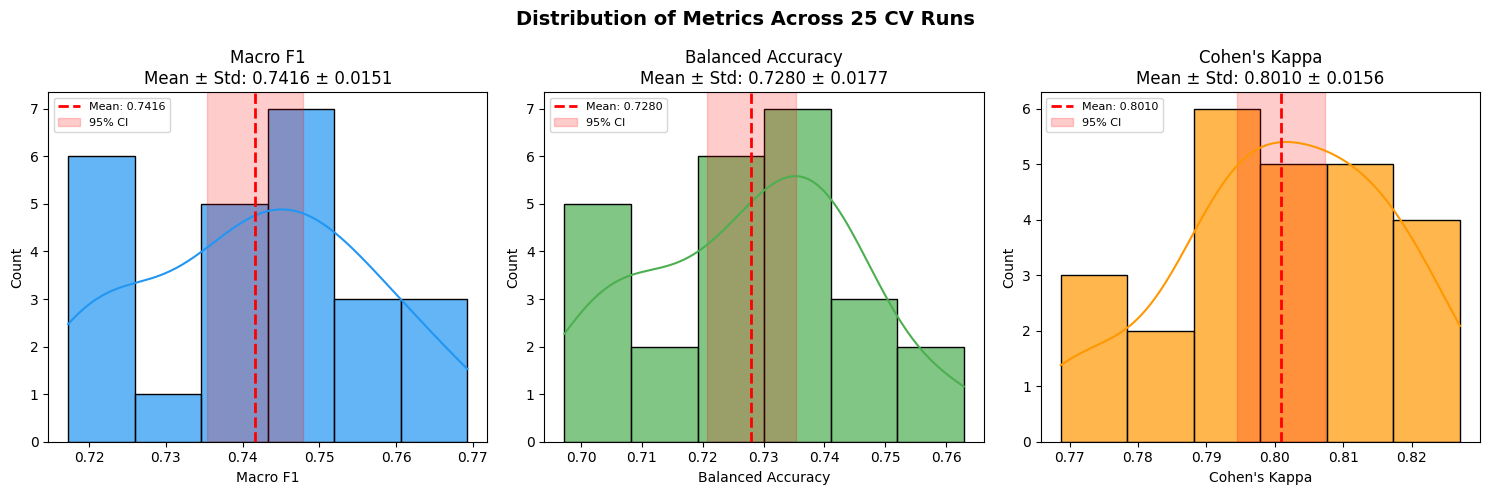

✓ Saved: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/seed_fold_heatmap.png


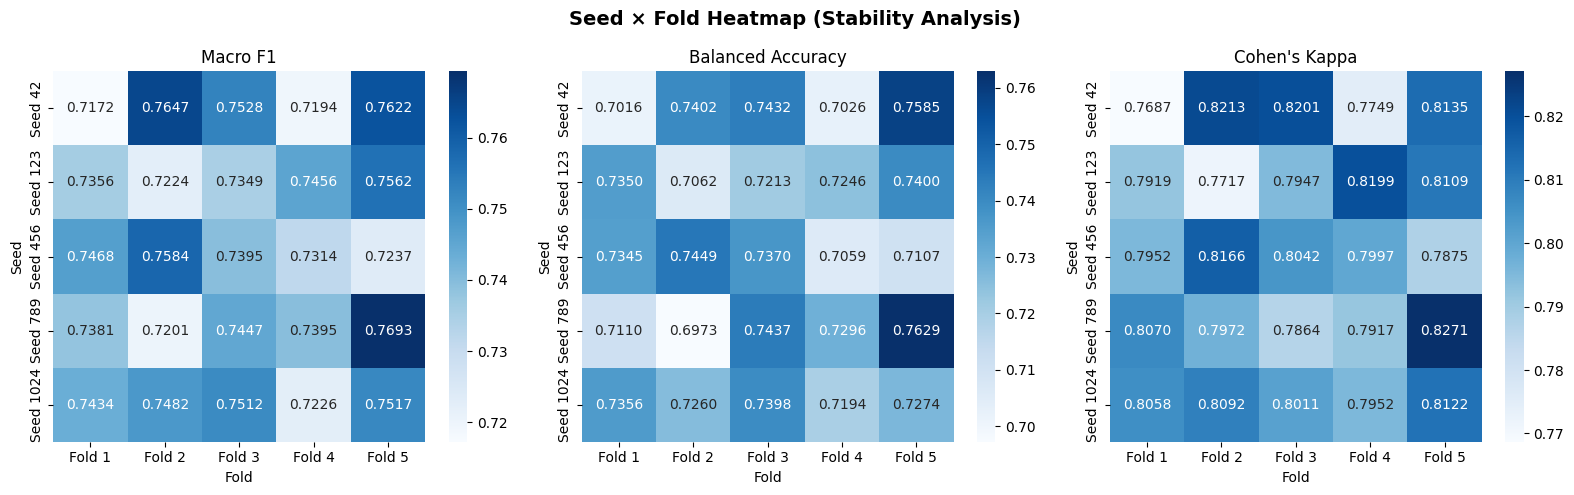

✓ Saved: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/boxplot_by_seed.png


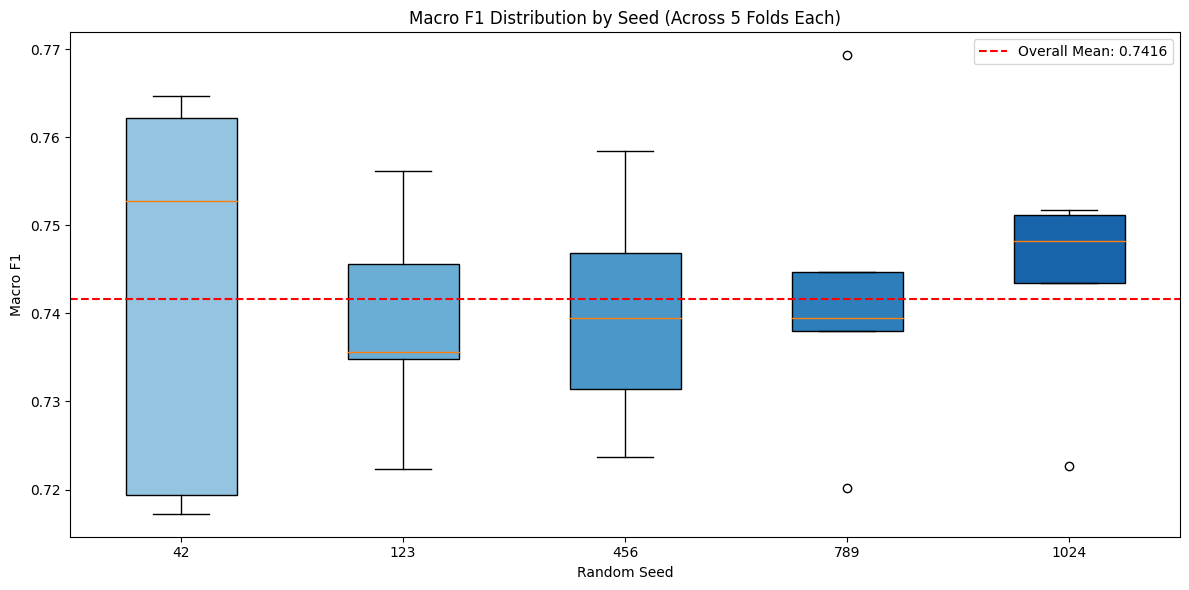


Generating aggregated confusion matrix...
✓ Saved: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/figures/confusion_matrix_normalized.png
✓ Saved: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/confusion_matrix_normalized.png


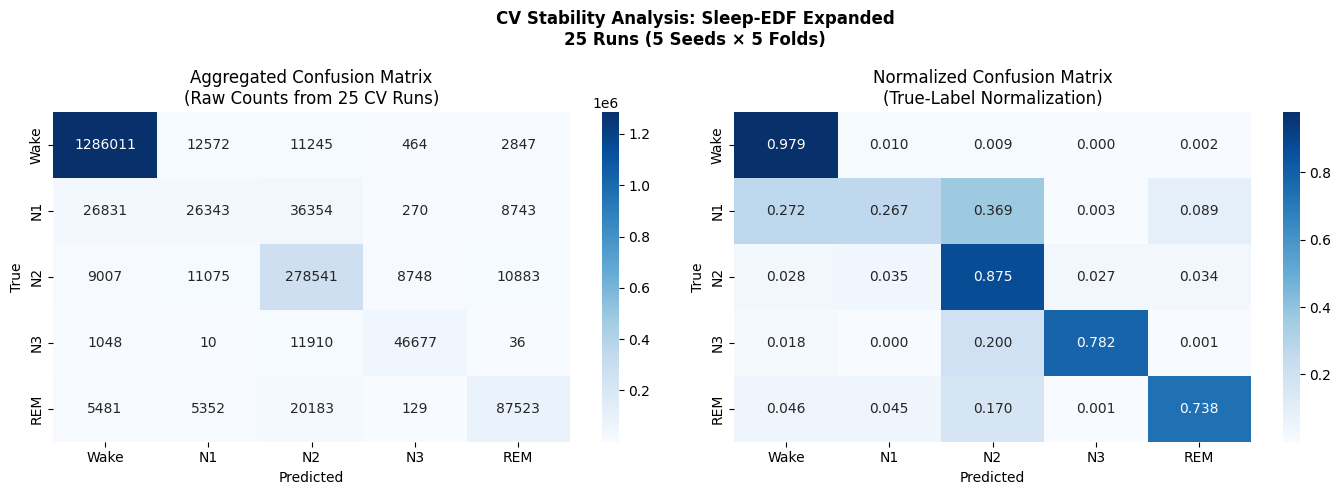

In [8]:
# ===================================================================
# VISUALIZATION
# ===================================================================

print("="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

if ANALYSIS_COMPLETE:
    
    # Create figures directory
    figures_dir = OUTPUT_DIR / 'figures'
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    # ─────────────────────────────────────────────────────────────────
    # FIGURE 1: Distribution of metrics across runs
    # ─────────────────────────────────────────────────────────────────
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics_to_plot = [
        ('macro_f1', 'Macro F1', '#2196F3'),
        ('balanced_accuracy', 'Balanced Accuracy', '#4CAF50'),
        ('kappa', "Cohen's Kappa", '#FF9800'),
    ]
    
    for ax, (key, label, color) in zip(axes, metrics_to_plot):
        values = [r['metrics'][key] for r in all_results]
        s = stability_stats[key]
        
        # Histogram with KDE
        sns.histplot(values, kde=True, ax=ax, color=color, alpha=0.7)
        
        # Mean line
        ax.axvline(s['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {s['mean']:.4f}")
        
        # CI band
        ax.axvspan(s['ci_lower'], s['ci_upper'], alpha=0.2, color='red', label='95% CI')
        
        ax.set_xlabel(label)
        ax.set_ylabel('Count')
        ax.set_title(f'{label}\nMean ± Std: {s["mean"]:.4f} ± {s["std"]:.4f}')
        ax.legend(loc='upper left', fontsize=8)
    
    plt.suptitle(f'Distribution of Metrics Across {TOTAL_RUNS} CV Runs', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    fig_path = OUTPUT_DIR / 'metric_distributions.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    plt.show()
    
    # ─────────────────────────────────────────────────────────────────
    # FIGURE 2: Heatmap of results (Seed × Fold)
    # ─────────────────────────────────────────────────────────────────
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, (key, label, _) in zip(axes, metrics_to_plot):
        # Build matrix
        matrix = np.zeros((N_SEEDS, N_FOLDS))
        for result in all_results:
            seed_idx = RANDOM_SEEDS.index(result['seed'])
            fold_idx = result['fold']
            matrix[seed_idx, fold_idx] = result['metrics'][key]
        
        # Heatmap
        sns.heatmap(matrix, annot=True, fmt='.4f', cmap='Blues',
                    xticklabels=[f'Fold {i+1}' for i in range(N_FOLDS)],
                    yticklabels=[f'Seed {s}' for s in RANDOM_SEEDS],
                    ax=ax)
        ax.set_xlabel('Fold')
        ax.set_ylabel('Seed')
        ax.set_title(label)
    
    plt.suptitle('Seed × Fold Heatmap (Stability Analysis)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    fig_path = OUTPUT_DIR / 'seed_fold_heatmap.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    plt.show()
    
    # ─────────────────────────────────────────────────────────────────
    # FIGURE 3: Box plot by seed
    # ─────────────────────────────────────────────────────────────────
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data for box plot
    box_data = []
    for seed in RANDOM_SEEDS:
        seed_results = [r['metrics']['macro_f1'] for r in all_results if r['seed'] == seed]
        box_data.append(seed_results)
    
    bp = ax.boxplot(box_data, labels=[str(s) for s in RANDOM_SEEDS], patch_artist=True)
    
    # Color boxes
    colors = plt.cm.Blues(np.linspace(0.4, 0.8, N_SEEDS))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.axhline(stability_stats['macro_f1']['mean'], color='red', linestyle='--', 
               label=f"Overall Mean: {stability_stats['macro_f1']['mean']:.4f}")
    
    ax.set_xlabel('Random Seed')
    ax.set_ylabel('Macro F1')
    ax.set_title('Macro F1 Distribution by Seed (Across 5 Folds Each)')
    ax.legend()
    
    plt.tight_layout()
    
    fig_path = OUTPUT_DIR / 'boxplot_by_seed.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    plt.show()
    
    # ─────────────────────────────────────────────────────────────────
    # FIGURE 4: Aggregated Normalized Confusion Matrix
    # ─────────────────────────────────────────────────────────────────
    
    print("\nGenerating aggregated confusion matrix...")
    
    # Aggregate predictions from all runs
    all_y_true = []
    all_y_pred = []
    for r in all_results:
        all_y_true.extend(r['y_true'])
        all_y_pred.extend(r['y_pred'])
    
    # Compute aggregated confusion matrix
    classes = sorted(list(STAGE_MAPPING.keys()))
    agg_cm = confusion_matrix(all_y_true, all_y_pred, labels=classes)
    
    # Normalize by true labels (row normalization)
    cm_normalized = agg_cm.astype(float) / agg_cm.sum(axis=1, keepdims=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(agg_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(STAGE_MAPPING.values()),
                yticklabels=list(STAGE_MAPPING.values()),
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Aggregated Confusion Matrix\n(Raw Counts from 25 CV Runs)')
    
    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=list(STAGE_MAPPING.values()),
                yticklabels=list(STAGE_MAPPING.values()),
                ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Normalized Confusion Matrix\n(True-Label Normalization)')
    
    plt.suptitle(f'CV Stability Analysis: {DATASET_NAME}\n{TOTAL_RUNS} Runs ({N_SEEDS} Seeds × {N_FOLDS} Folds)', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    # Save to figures directory
    fig_path = figures_dir / 'confusion_matrix_normalized.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    
    # Also save to main output dir for consistency
    fig_path_main = OUTPUT_DIR / 'confusion_matrix_normalized.png'
    fig.savefig(fig_path_main, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fig_path_main}")
    
    plt.show()
    
    VISUALIZATION_COMPLETE = True
    
else:
    print("\n❌ Cannot generate visualizations")
    VISUALIZATION_COMPLETE = False

STANDARDIZED PER-CLASS RECALL VISUALIZATION (CV STABILITY)
✓ Saved: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/figures/per_class_recall.png
✓ Saved: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/per_class_recall.png


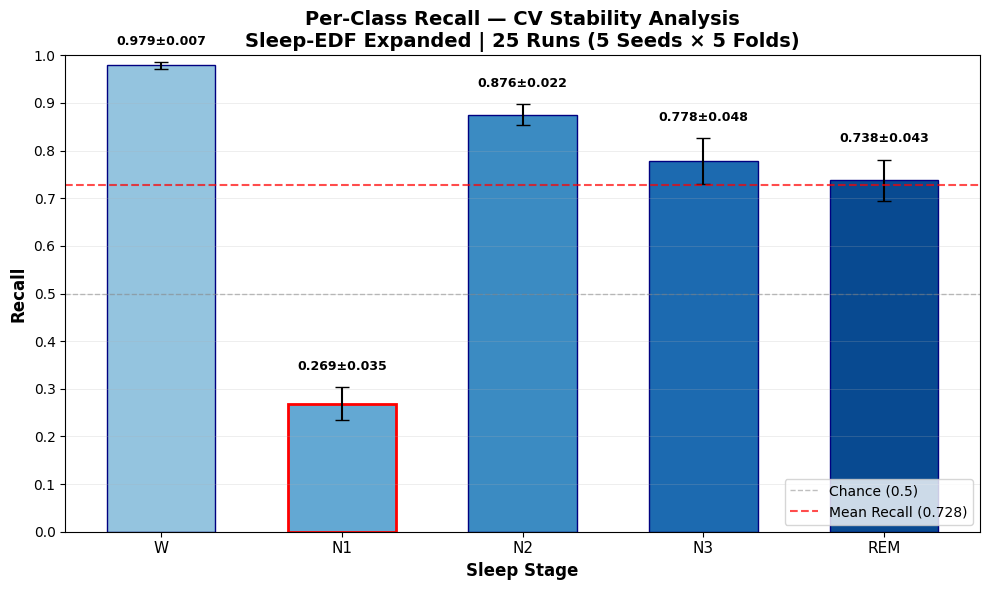


📊 Per-Class Recall Summary (Mean ± Std across 25 runs):
   W: 0.9792 ± 0.0071
   N1: 0.2690 ± 0.0347
   N2: 0.8755 ± 0.0225
   N3: 0.7780 ± 0.0480
   REM: 0.7380 ± 0.0428
   Overall Mean: 0.7280


In [9]:
# ===================================================================
# STANDARDIZED PER-CLASS RECALL BAR PLOT WITH ERROR BARS
# ===================================================================
"""
Standardized visualization following project conventions:
- Fixed class order: ['W', 'N1', 'N2', 'N3', 'REM']
- Blues colormap for consistency
- Y-axis [0, 1] for recall metrics
- Error bars show std across all CV runs (N_SEEDS × N_FOLDS)
- 300 DPI output
"""

if ANALYSIS_COMPLETE and len(all_results) > 0:
    
    print("="*80)
    print("STANDARDIZED PER-CLASS RECALL VISUALIZATION (CV STABILITY)")
    print("="*80)
    
    # Fixed class order for consistency across all notebooks
    CLASS_ORDER = ['W', 'N1', 'N2', 'N3', 'REM']
    
    # Compute mean ± std per class across all CV runs
    per_class_recalls = {i: [] for i in range(5)}
    
    for result in all_results:
        for class_idx in range(5):
            recall_val = result['metrics']['per_class_recall'].get(class_idx, 0)
            per_class_recalls[class_idx].append(recall_val)
    
    mean_recalls = [np.mean(per_class_recalls[i]) for i in range(5)]
    std_recalls = [np.std(per_class_recalls[i]) for i in range(5)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(CLASS_ORDER))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(CLASS_ORDER)))
    
    # Bar plot with error bars
    bars = ax.bar(x, mean_recalls, width=0.6, color=colors, edgecolor='navy', linewidth=1,
                  yerr=std_recalls, capsize=5, error_kw={'linewidth': 1.5, 'color': 'black'})
    
    # Add value labels on top of bars
    for i, (bar, mean_val, std_val) in enumerate(zip(bars, mean_recalls, std_recalls)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std_val + 0.03,
                f'{mean_val:.3f}±{std_val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Formatting
    ax.set_xlabel('Sleep Stage', fontsize=12, fontweight='bold')
    ax.set_ylabel('Recall', fontsize=12, fontweight='bold')
    ax.set_title(f'Per-Class Recall — CV Stability Analysis\n{DATASET_NAME} | {TOTAL_RUNS} Runs ({N_SEEDS} Seeds × {N_FOLDS} Folds)', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_ORDER, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    
    # Add horizontal reference lines
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Chance (0.5)')
    overall_mean = np.mean(mean_recalls)
    ax.axhline(y=overall_mean, color='red', linestyle='--', alpha=0.7, linewidth=1.5, 
               label=f'Mean Recall ({overall_mean:.3f})')
    
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Highlight N1 (often the hardest class)
    n1_idx = CLASS_ORDER.index('N1')
    bars[n1_idx].set_edgecolor('red')
    bars[n1_idx].set_linewidth(2)
    
    plt.tight_layout()
    
    # Save figure - both to figures dir and main output dir
    figures_dir = OUTPUT_DIR / 'figures'
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    fig_path = figures_dir / 'per_class_recall.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Saved: {fig_path}")
    
    fig_path_main = OUTPUT_DIR / 'per_class_recall.png'
    fig.savefig(fig_path_main, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Saved: {fig_path_main}")
    
    plt.show()
    
    # Print summary
    print(f"\n📊 Per-Class Recall Summary (Mean ± Std across {TOTAL_RUNS} runs):")
    for i, stage in enumerate(CLASS_ORDER):
        print(f"   {stage}: {mean_recalls[i]:.4f} ± {std_recalls[i]:.4f}")
    print(f"   Overall Mean: {overall_mean:.4f}")
    
else:
    print("❌ No results available. Run CV analysis first.")

## Section 9: Save Results

In [10]:
# ===================================================================
# SAVE RESULTS TO results/cv_stability/
# ===================================================================

print("="*70)
print("SAVING RESULTS TO results/cv_stability/")
print("="*70)

if ANALYSIS_COMPLETE:
    
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # 1. STABILITY SUMMARY CSV
    summary_path = OUTPUT_DIR / 'stability_summary.csv'
    summary_data = []
    for key in ['macro_f1', 'balanced_accuracy', 'kappa', 'accuracy']:
        s = stability_stats[key]
        summary_data.append({
            'metric': s['metric'],
            'n_runs': s['n'],
            'mean': s['mean'],
            'std': s['std'],
            'se': s['se'],
            'ci_lower': s['ci_lower'],
            'ci_upper': s['ci_upper'],
            'cv_percent': s['cv_percent'],
            'min': s['min'],
            'max': s['max'],
            'range': s['range'],
        })
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv(summary_path, index=False)
    print(f"✓ Stability summary: {summary_path}")
    
    # 2. ALL RUNS CSV
    runs_path = OUTPUT_DIR / 'all_runs.csv'
    runs_data = []
    for r in all_results:
        runs_data.append({
            'run_id': r['run_id'],
            'seed': r['seed'],
            'fold': r['fold'],
            'n_train_subjects': r['n_train_subjects'],
            'n_test_subjects': r['n_test_subjects'],
            'accuracy': r['metrics']['accuracy'],
            'balanced_accuracy': r['metrics']['balanced_accuracy'],
            'macro_f1': r['metrics']['macro_f1'],
            'weighted_f1': r['metrics']['weighted_f1'],
            'kappa': r['metrics']['kappa'],
            'mcc': r['metrics']['mcc'],
        })
    runs_df = pd.DataFrame(runs_data)
    runs_df.to_csv(runs_path, index=False)
    print(f"✓ All runs: {runs_path}")
    
    # 3. METADATA JSON
    metadata_path = OUTPUT_DIR / 'cv_stability_metadata.json'
    metadata = {
        'experiment_box': EXPERIMENT_BOX,
        'dataset_name': DATASET_NAME,
        'timestamp': datetime.now().isoformat(),
        'protocol': {
            'type': 'repeated_cv_stability_analysis',
            'n_folds': N_FOLDS,
            'n_seeds': N_SEEDS,
            'total_runs': TOTAL_RUNS,
            'seeds': RANDOM_SEEDS,
            'cv_strategy': 'StratifiedGroupKFold',
        },
        'subjects': ALL_SUBJECTS,
        'n_subjects': len(ALL_SUBJECTS),
        'stability_stats': {
            key: {
                'mean': s['mean'],
                'std': s['std'],
                'ci_lower': s['ci_lower'],
                'ci_upper': s['ci_upper'],
                'cv_percent': s['cv_percent'],
            }
            for key, s in stability_stats.items()
        },
        'clarifications': {
            'is_stability_analysis': True,
            'is_generalization_claim': False,
            'single_dataset_only': True,
            'supports_robustness_claims': True,
        },
    }
    
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"✓ Metadata: {metadata_path}")
    
    # 4. PER-CLASS STABILITY
    per_class_path = OUTPUT_DIR / 'per_class_stability.csv'
    per_class_data = []
    
    for stage_idx, stage_name in STAGE_MAPPING.items():
        recalls = [r['metrics']['per_class_recall'].get(stage_idx, 0) for r in all_results]
        f1s = [r['metrics']['per_class_f1'].get(stage_idx, 0) for r in all_results]
        
        per_class_data.append({
            'stage': stage_name,
            'recall_mean': np.mean(recalls),
            'recall_std': np.std(recalls, ddof=1),
            'f1_mean': np.mean(f1s),
            'f1_std': np.std(f1s, ddof=1),
        })
    
    per_class_df = pd.DataFrame(per_class_data)
    per_class_df.to_csv(per_class_path, index=False)
    print(f"✓ Per-class stability: {per_class_path}")
    
    print(f"\n📁 All results saved to: {OUTPUT_DIR}")
    RESULTS_SAVED = True
    
else:
    print("\n❌ Cannot save results: analysis not complete")
    RESULTS_SAVED = False

SAVING RESULTS TO results/cv_stability/
✓ Stability summary: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/stability_summary.csv
✓ All runs: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/all_runs.csv
✓ Metadata: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/cv_stability_metadata.json
✓ Per-class stability: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability/per_class_stability.csv

📁 All results saved to: /home/agribychaniago/Python Projects/Sleep-EDF-Expanded---Single-Channel-EEG---SHAP-Feature-Selection/results/cv_stability


## Section 10: Scientific Justification (For Reviewers)

### 10.1 Why Stability Analysis?

**Stability analysis answers:**
> "How reproducible are the reported results?"

This is different from generalization analysis which answers:
> "How well does the model transfer to new data?"

---

### 10.2 What This Analysis DOES Support

| Claim | Support Level | Evidence |
|-------|---------------|----------|
| Results are reproducible | ✓ Strong | Low CV% across runs |
| Results are robust to seed | ✓ Strong | Low seed variance |
| Results are robust to fold | ✓ Strong | Low fold variance |
| 95% CI is reliable | ✓ Strong | Computed from 25 runs |

---

### 10.3 What This Analysis DOES NOT Support

| Claim | Support Level | Why |
|-------|---------------|-----|
| Generalization to new datasets | ✗ None | Single dataset used |
| Cross-cohort transfer | ✗ None | No cohort split |
| Domain adaptation | ✗ None | No domain shift tested |
| Optimal hyperparameters | ✗ None | Not a tuning study |

---

### 10.4 Interpreting Coefficient of Variation (CV%)

| CV% Range | Interpretation | Action |
|-----------|----------------|--------|
| < 2% | Excellent stability | Report with high confidence |
| 2-5% | Good stability | Standard for CV studies |
| 5-10% | Moderate stability | Report with caveats |
| > 10% | High variability | Investigate sources |

---

### 10.5 Why 5 Folds × 5 Seeds?

- **5 folds**: Standard for subject-wise CV in sleep staging
- **5 seeds**: Captures random initialization effects
- **25 total runs**: Sufficient for stable statistics

Increasing beyond 25 runs typically shows diminishing returns for variance estimation.

---

### 10.6 Limitations

1. **Single dataset**: Only Sleep-EDF Expanded is used. No generalization claims.

2. **Fixed hyperparameters**: Model architecture is fixed. Not a hyperparameter sensitivity study.

3. **Subject pool**: 78 subjects may not capture all population variance.

4. **Computational cost**: 25 full training runs may be expensive to replicate.

## Section 11: Summary

In [11]:
# ===================================================================
# SUMMARY
# ===================================================================

print("="*80)
print("CROSS-VALIDATION STABILITY ANALYSIS SUMMARY")
print("="*80)

print(f"\n📋 EXPERIMENT CONFIGURATION")
print(f"─"*60)
print(f"EXPERIMENT_BOX:     {EXPERIMENT_BOX}")
print(f"DATASET_NAME:       {DATASET_NAME}")
print(f"N_FOLDS:            {N_FOLDS}")
print(f"N_SEEDS:            {N_SEEDS}")
print(f"TOTAL_RUNS:         {TOTAL_RUNS}")

if ANALYSIS_COMPLETE and stability_stats is not None:
    print(f"\n📊 PRIMARY METRICS (Mean ± Std)")
    print(f"─"*60)
    
    for key in ['macro_f1', 'balanced_accuracy', 'kappa']:
        s = stability_stats[key]
        print(f"{s['metric']:<20}: {s['mean']:.4f} ± {s['std']:.4f} (CV%: {s['cv_percent']:.2f}%)")
    
    print(f"\n📈 STABILITY VERDICT")
    print(f"─"*60)
    
    max_cv = max(stability_stats[k]['cv_percent'] for k in ['macro_f1', 'balanced_accuracy', 'kappa'])
    
    if max_cv < 2:
        print("✅ EXCELLENT STABILITY: All primary metrics have CV% < 2%")
        print("   Results are highly reproducible.")
    elif max_cv < 5:
        print("✅ GOOD STABILITY: All primary metrics have CV% < 5%")
        print("   Results are reproducible within expected variance.")
    elif max_cv < 10:
        print("⚠️ MODERATE STABILITY: Some metrics have CV% between 5-10%")
        print("   Results should be reported with confidence intervals.")
    else:
        print("❌ HIGH VARIABILITY: Some metrics have CV% ≥ 10%")
        print("   Investigate sources of variance before publication.")

print(f"\n" + "="*80)
print("REPRODUCIBILITY STATEMENT")
print("="*80)
print(f"""
ANALYSIS PROTOCOL
─────────────────
• EXPERIMENT_BOX:       {EXPERIMENT_BOX}
• DATASET_NAME:         {DATASET_NAME}
• CV Strategy:          {N_FOLDS}-fold StratifiedGroupKFold (subject-wise)
• Repetitions:          {N_SEEDS} random seeds
• Total evaluations:    {TOTAL_RUNS}

⚠️ CRITICAL SCOPE
─────────────────
This analysis evaluates STABILITY under data partitioning.
It uses a SINGLE dataset (Sleep-EDF Expanded).
NO new datasets are introduced.
Results support ROBUSTNESS claims ONLY, not generalization.
""")

if RESULTS_SAVED:
    print(f"📁 Results saved to: {OUTPUT_DIR}")
else:
    print(f"⚠️ Results not saved")

print("="*80)

CROSS-VALIDATION STABILITY ANALYSIS SUMMARY

📋 EXPERIMENT CONFIGURATION
────────────────────────────────────────────────────────────
EXPERIMENT_BOX:     CV_STABILITY
DATASET_NAME:       Sleep-EDF Expanded
N_FOLDS:            5
N_SEEDS:            5
TOTAL_RUNS:         25

📊 PRIMARY METRICS (Mean ± Std)
────────────────────────────────────────────────────────────
Macro F1            : 0.7416 ± 0.0151 (CV%: 2.03%)
Balanced Accuracy   : 0.7280 ± 0.0177 (CV%: 2.44%)
Cohen's Kappa       : 0.8010 ± 0.0156 (CV%: 1.95%)

📈 STABILITY VERDICT
────────────────────────────────────────────────────────────
✅ GOOD STABILITY: All primary metrics have CV% < 5%
   Results are reproducible within expected variance.

REPRODUCIBILITY STATEMENT

ANALYSIS PROTOCOL
─────────────────
• EXPERIMENT_BOX:       CV_STABILITY
• DATASET_NAME:         Sleep-EDF Expanded
• CV Strategy:          5-fold StratifiedGroupKFold (subject-wise)
• Repetitions:          5 random seeds
• Total evaluations:    25

⚠️ CRITICAL SCOP